# バックテスト doe-001

DD_PROFIT と DD_RATIO の依存性調査

In [15]:
import os
import sys

path_up = os.path.join("..", "..")
if not path_up in sys.path:
    sys.path.append(path_up)

In [16]:
import glob

import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

from funcs.tse import get_ticker_name_list

## 基本情報

In [17]:
# 実験名
name_doe = "doe-001"
param_1 = "DD_PROFIT"
param_2 = "DD_RATIO"
# 銘柄コード
code: str = "9984"
name = get_ticker_name_list([code])[code]
print(name)

# 実験表の読み込み
path_csv = os.path.join("..", f"{name_doe}.csv")
df_doe = pd.read_csv(path_csv)[[param_1, param_2]]
print(df_doe)

ソフトバンクグループ
    DD_PROFIT  DD_RATIO
0          10       0.1
1          10       0.2
2          10       0.3
3          10       0.4
4          10       0.5
..        ...       ...
58         70       0.5
59         70       0.6
60         70       0.7
61         70       0.8
62         70       0.9

[63 rows x 2 columns]


## すべての結果を読み込む

In [18]:
# 結果の CSV ファイル一覧を抽出してソード
list_file: list[str] = sorted(glob.glob(f"{code}/*/{code}_result.csv"))
# ファイルをひとつひとつ読み込んでリストに保持
list_df: list[pd.DataFrame] = []
for file in list_file:
    list_df.append(pd.read_csv(file))
# 縦に連結してインデックスを振り直す
df = pd.concat(list_df, axis=0).reset_index(drop=True)
# 年月日の date 列を datetime 型に変換
df["date"] = pd.to_datetime(df["date"])
df.columns

Index(['date', 'run', 'PERIOD_WARMUP', 'BAND_VWAP', 'PERIOD_MA_1',
       'PERIOD_RSI', 'PERIOD_MOM', 'DD_PROFIT', 'DD_RATIO', 'LOSSCUT_1',
       'N_MINUS_MAX', 'trade', 'total'],
      dtype='str')

## 集計

In [19]:
# ユニークな実験 run 数
list_run = sorted(list(set(df["run"])))
# run 毎の集計
list_ser_total: list[pd.Series] = []  # 日別収益
list_ser_cumsum: list[pd.Series] = []  # 累積収益
list_median: list[float] = []  # 収益のメジアン
list_iqr: list[float] = []  # 収益のIQR
list_max: list[float] = []  # 収益の最大
list_min: list[float] = []  # 収益の最小
for run in list_run:
    # 指定した run の対象の列を抽出して "date" 列でソード
    df_run = (
        df[df["run"] == run][["date", "total"]]
        .reset_index(drop=True)
        .sort_values("date")
        .set_index("date")
    )
    # 日別収益
    ser_total = df_run["total"]
    ser_total.name = run
    list_ser_total.append(ser_total)

    # 累積収益
    ser_cumsum = df_run["total"].cumsum()
    ser_cumsum.name = run
    list_ser_cumsum.append(ser_cumsum)

    # メジアン
    v_med = df_run["total"].median()
    list_median.append(v_med)

    # 1. 第1四分位数(Q1)と第3四分位数(Q3)を計算
    v_q1 = df_run["total"].quantile(0.25)
    v_q3 = df_run["total"].quantile(0.75)
    # 2. IQRを計算
    list_iqr.append(v_q3 - v_q1)

    # 最大
    v_max = df_run["total"].max()
    list_max.append(v_max)

    # 最小
    v_min = df_run["total"].min()
    list_min.append(v_min)

In [20]:
print("\n# Daily Total")
df_total = pd.concat(list_ser_total, axis=1)
print(df_total.tail())

print("\n# Cumulative Total")
df_cumsum = pd.concat(list_ser_cumsum, axis=1)
print(df_cumsum.tail())

print("\n# Madian in the period")
ser_median = pd.Series(list_median, name="median")
print(ser_median)

print("\n# IQR in the period")
ser_iqr = pd.Series(list_median, name="iqr")
print(ser_iqr)

print("\n# Max in the period")
ser_max = pd.Series(list_max, name="max")
print(ser_max)

print("\n# Min in the period")
ser_min = pd.Series(list_min, name="min")
print(ser_min)


# Daily Total
                0       1       2       3       4       5       6        7   \
date                                                                          
2026-03-17  3900.0  3700.0  5500.0  6100.0  6500.0  6900.0  6500.0   5900.0   
2026-03-18  1100.0  1000.0  1000.0  1000.0   800.0   700.0   600.0    200.0   
2026-03-19  1400.0  1300.0  1000.0   100.0   300.0  -100.0 -1100.0  -1500.0   
2026-03-23  4400.0  3900.0  6100.0  5500.0  4400.0  4000.0  2300.0  10000.0   
2026-03-24  1700.0  1200.0  1400.0  1600.0   900.0   500.0     0.0   -800.0   

                8       9   ...      53      54      55      56      57  \
date                        ...                                           
2026-03-17  5100.0  3300.0  ...  -800.0  -800.0  -800.0  -800.0  -800.0   
2026-03-18   200.0  2100.0  ...  6700.0  6700.0  6700.0  6700.0  6700.0   
2026-03-19 -1900.0  2000.0  ...  4300.0  4800.0  4000.0  4300.0  4300.0   
2026-03-23   300.0 -1400.0  ... -4100.0 -4100.0 -4100.0 

### ランキング (Top 5)

In [21]:
# 累積収益の最下行（最新日）の収益でランキング
df_cumsum_latest = df_cumsum.tail(1)
dt_latest = df_cumsum_latest.index[0]
ser_ranking = df_cumsum_latest.T[dt_latest].sort_values(ascending=False)
# Top
list_tops = list(ser_ranking.head(5).index)
list_tops

[43, 34, 16, 28, 15]

In [22]:
ser_cumtotal = df_cumsum_latest.T[dt_latest]
ser_cumtotal.name = "cumtotal"
ser_cumtotal

0     11000.0
1     12800.0
2     25000.0
3     26200.0
4     25700.0
       ...   
58     9500.0
59      900.0
60    18900.0
61    17300.0
62    17100.0
Name: cumtotal, Length: 63, dtype: float64

## 累積収益トレンド

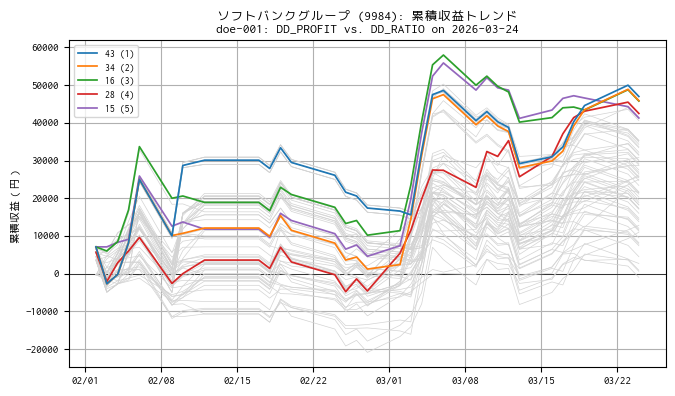

In [23]:
FONT_PATH = "../../fonts/RictyDiminished-Regular.ttf"
fm.fontManager.addfont(FONT_PATH)

# FontPropertiesオブジェクト生成（名前の取得のため）
font_prop = fm.FontProperties(fname=FONT_PATH)
font_prop.get_name()

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(6.8, 4))

ax.set_title(
    f"{name} ({code}): 累積収益トレンド\n"
    f"{name_doe}: {param_1} vs. {param_2} on {dt_latest.date()}"
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.set_ylabel("累積収益（円）")

for colname in list_tops:
    ser = df_cumsum[colname]
    d = list_tops.index(colname)
    ax.plot(ser, linewidth=1.25, zorder=50 - d, label=f"{colname:02d} ({d+1})")

for colname in df_cumsum.columns:
    ser = df_cumsum[colname]
    if colname not in list_tops:
        ax.plot(ser, color="lightgray", linewidth=0.5, zorder=5)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.legend(fontsize=7)
ax.grid()
plt.tight_layout()
name_img = f"{dt_latest.date()}_{code}_cumsum.png"
plt.savefig(name_img)
plt.show()

## 日毎の収益

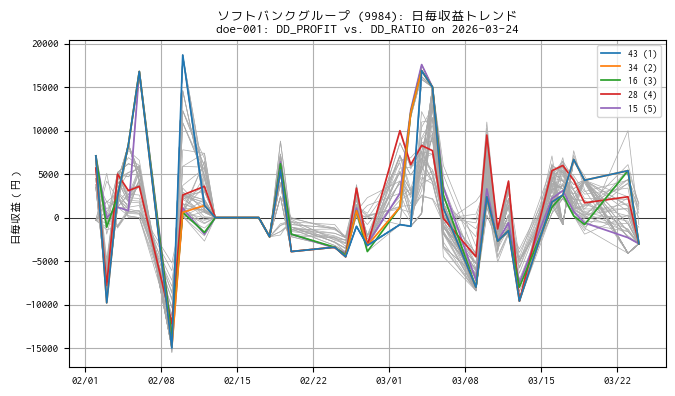

In [24]:
fig, ax = plt.subplots(figsize=(6.8, 4))

ax.set_title(
    f"{name} ({code}): 日毎収益トレンド\n"
    f"{name_doe}: {param_1} vs. {param_2} on {dt_latest.date()}"
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.set_ylabel("日毎収益（円）")

for colname in list_tops:
    ser = df_total[colname]
    d = list_tops.index(colname)
    ax.plot(ser, linewidth=1.25, zorder=50 - d, label=f"{colname:02d} ({d+1})")

for colname in df_cumsum.columns:
    ser = df_total[colname]
    if colname not in list_tops:
        ax.plot(ser, color="#aaa", linewidth=0.5, zorder=5)

ax.axhline(y=0, color="black", linewidth=0.5)
ax.legend(fontsize=7)
ax.grid()
plt.tight_layout()
name_img = f"{dt_latest.date()}_{code}_total.png"
plt.savefig(name_img)
plt.show()

In [25]:
df_summary = pd.DataFrame(
    {
        "DD_PROFIT": df_doe["DD_PROFIT"],
        "DD_RATIO": df_doe["DD_RATIO"],
        "CumSum": ser_cumtotal,
        "Median": ser_median,
        "IQR": ser_iqr,
        "Max": ser_max,
        "Min": ser_min,
    }
)

(
    df_summary.style.set_table_attributes('class="simple"')
    .set_properties(**{"text-align": "right"})
    .format(precision=1, thousands=",")
    .to_html(f"{dt_latest.date()}_{code}_summary.html", index=False)
)

df_summary

,DD_PROFIT,DD_RATIO,CumSum,Median,IQR,Max,Min
0,10,0.1,11000.0,150.0,150.0,4400.0,-5200.0
1,10,0.2,12800.0,450.0,450.0,6400.0,-6100.0
2,10,0.3,25000.0,500.0,500.0,6500.0,-7200.0
3,10,0.4,26200.0,300.0,300.0,8800.0,-7900.0
4,10,0.5,25700.0,400.0,400.0,9800.0,-8500.0
...,...,...,...,...,...,...,...
58,70,0.5,9500.0,-400.0,-400.0,18700.0,-15000.0
59,70,0.6,900.0,-400.0,-400.0,18700.0,-15000.0
60,70,0.7,18900.0,-300.0,-300.0,18700.0,-15000.0
61,70,0.8,17300.0,-400.0,-400.0,18700.0,-15000.0


In [26]:
row_best = list_tops[0]
df_summary_best = df_summary.iloc[row_best : row_best + 1]
(
    df_summary_best.style.set_table_attributes('class="simple"')
    .set_properties(**{"text-align": "right"})
    .format(precision=1, thousands=",")
    .to_html(f"{dt_latest.date()}_{code}_summary_best.html", index=False)
)
df_summary_best

,DD_PROFIT,DD_RATIO,CumSum,Median,IQR,Max,Min
43,50,0.8,47000.0,0.0,0.0,18700.0,-15000.0
